# GOOGL Stock Movement Prediction
## Part 5: Temporal Fusion Transformer (TFT)

The Temporal Fusion Transformer (Lim et al., 2021) is an attention-based architecture designed specifically for multi-horizon time series forecasting with heterogeneous input types. Key components relevant to this project:

- **Variable Selection Networks (VSN):** learn per-timestep feature
  importance, effectively performing soft feature selection during training.
  This handles the mixed-quality feature set (strong technical indicators
  alongside sparse fundamental features) without manual pre-selection.
- **Gated Residual Networks (GRN):** non-linear transformation with
  skip connections, providing depth without vanishing gradients.
- **Multi-head attention:** captures temporal dependencies at multiple
  scales simultaneously.
- **Quantile outputs:** the architecture natively supports probabilistic
  forecasting; we use the median (q0.5) as the point prediction to match
  LightGBM's point forecast for fair comparison.

**Feature set:** uses `sequence_model_features` from Part 3 (89 features —
excludes non-stationary level features like raw SMA, CPI level, pb_ratio
level, etc. that were kept for LightGBM but are inappropriate for a model
sensitive to input distribution shifts).

**Architecture note:** TFT is evaluated against the same walk-forward split
(train 2014-2021, val 2022-2023, test 2024-2026) and the same simulated
trading strategy logic (non-overlapping rebalance) used in Part 4.

In [15]:
!pip install pytorch-forecasting lightning torch pandas numpy matplotlib

In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
 
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer, MultiNormalizer, TorchNormalizer
from pytorch_forecasting.metrics import QuantileLoss, MAE
 
warnings.filterwarnings("ignore")
pl.seed_everything(42)
 
PROCESSED_DIR = "data/processed"
MODEL_DIR     = "models"
os.makedirs(MODEL_DIR, exist_ok=True)
 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    n_gpus = torch.cuda.device_count()
    print(f"GPUs   : {n_gpus}")
else:
    print("Warning: no GPU detected. Training will be slow.")

Seed set to 42


Device : cuda
GPU    : Tesla T4
GPUs   : 2


In [17]:
df_raw = pd.read_csv(f"{PROCESSED_DIR}/features.csv", index_col=0, parse_dates=True)
 
with open(f"{PROCESSED_DIR}/split_index.json") as fh:
    split_index = json.load(fh)
 
with open(f"{PROCESSED_DIR}/selected_features.json") as fh:
    selected = json.load(fh)
 
SEQ_FEATURES = selected["sequence_model_features"]
TARGET_COLS  = selected["target_columns"]
HORIZONS     = {"target_return_1d": "1d", "target_return_5d": "5d", "target_return_20d": "20d"}
HORIZON_DAYS = {"1d": 1, "5d": 5, "20d": 20}
 
print(f"Dataset shape      : {df_raw.shape}")
print(f"Sequence features  : {len(SEQ_FEATURES)}")
print(f"Targets            : {TARGET_COLS}")
print(f"Train              : {split_index['train_start']} to {split_index['train_end']}")
print(f"Val                : {split_index['val_start']} to {split_index['val_end']}")
print(f"Test               : {split_index['test_start']} to {split_index['test_end']}")

Dataset shape      : (3134, 157)
Sequence features  : 89
Targets            : ['target_return_1d', 'target_return_5d', 'target_return_20d']
Train              : 2014-01-01 to 2021-12-31
Val                : 2022-01-01 to 2023-12-31
Test               : 2024-01-01 to 2026-06-18


## Data Preparation for TFT

`pytorch-forecasting` requires the data in a specific tabular format with:
- An integer time index column (not a DatetimeIndex)
- A group identifier column (for multi-series; we have one series, GOOGL)
- A defined encoder length (how many past timesteps the model sees)
- A defined prediction length (how many steps ahead it predicts)

**Encoder length:** 60 trading days (~3 months). Long enough to capture
medium-term trends and seasonality visible to the technical features,
without making training prohibitively expensive given dataset size.

**Key design decision — NaN handling:**
TFT requires no NaN values in inputs. The sparse fundamental columns
(those with availability masks) are imputed with forward-fill then
backward-fill. Rows where the target itself is NaN (the final n rows
where we have no future price) are dropped from training/val, but kept
for inference by replacing target NaN with 0 temporarily.

In [18]:
ENCODER_LENGTH = 60
PREDICTION_LENGTH = 1  # TFT predicts 1 step; we train separate models per horizon
 
def prepare_tft_dataframe(df: pd.DataFrame, feature_cols: list,
                           target_col: str) -> pd.DataFrame:
    """
    Produces a clean DataFrame suitable for TimeSeriesDataSet:
    - integer time_idx column (row number)
    - group_id column (single value since we have one ticker)
    - all feature_cols with NaN imputed
    - target column (NaN rows used for inference only, masked during training)
    """
    tft_df = df[feature_cols + [target_col]].copy()
 
    # Forward-fill then backward-fill to eliminate NaN in features
    tft_df[feature_cols] = tft_df[feature_cols].ffill().bfill()
 
    # Any remaining NaN (e.g. all-NaN columns) → fill with 0
    tft_df[feature_cols] = tft_df[feature_cols].fillna(0.0)
 
    tft_df["group_id"] = "GOOGL"
    tft_df["time_idx"] = np.arange(len(tft_df))
    tft_df["date"]     = df.index
 
    # Store original target NaN mask for evaluation (rows with no future price)
    tft_df["target_available"] = tft_df[target_col].notna().astype(int)
 
    # For training: fill NaN target with 0 (these rows will not contribute
    # to loss due to the mask — confirmed below in TimeSeriesDataSet setup)
    tft_df[target_col] = tft_df[target_col].fillna(0.0)
 
    return tft_df.reset_index(drop=True)

In [19]:
def build_datasets(tft_df: pd.DataFrame, target_col: str,
                   feature_cols: list, split_index: dict):
    """
    Returns (train_dataset, val_dataset) as TimeSeriesDataSet objects,
    and the full tft_df with time_idx for later prediction.
    """
    train_cutoff_idx = tft_df[tft_df["date"] <= split_index["train_end"]]["time_idx"].max()
    val_cutoff_idx   = tft_df[tft_df["date"] <= split_index["val_end"]]["time_idx"].max()
 
    train_dataset = TimeSeriesDataSet(
        tft_df[tft_df["time_idx"] <= train_cutoff_idx],
        time_idx="time_idx",
        target=target_col,
        group_ids=["group_id"],
        min_encoder_length=ENCODER_LENGTH // 2,
        max_encoder_length=ENCODER_LENGTH,
        min_prediction_length=PREDICTION_LENGTH,
        max_prediction_length=PREDICTION_LENGTH,
        time_varying_known_reals=[],
        time_varying_unknown_reals=feature_cols,
        target_normalizer=TorchNormalizer(method="robust", center=True),
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
        allow_missing_timesteps=False,
    )
 
    val_dataset = TimeSeriesDataSet.from_dataset(
        train_dataset,
        tft_df[tft_df["time_idx"] <= val_cutoff_idx],
        predict=False,
        stop_randomization=True,
    )
 
    return train_dataset, val_dataset

## TFT Architecture and Training

Architecture parameters are conservative given the dataset size:
- `hidden_size=64`: embedding dimension. Larger values overfit on ~2000
  training samples. 64 is the recommended starting point for datasets
  under 5k rows in the pytorch-forecasting documentation.
- `attention_head_size=4`: number of attention heads in multi-head
  attention. 4 heads × 16-dim each = 64 total, matching hidden_size.
- `dropout=0.2`: applied to GRN outputs and attention weights.
- `hidden_continuous_size=32`: size of continuous variable embeddings
  before they enter the variable selection network.

Training uses the AdamW optimizer with cosine annealing LR schedule
(handled by pytorch-lightning's built-in LR scheduler), early stopping
on validation MAE with patience 10 epochs.

In [20]:
TFT_HPARAMS = {
    "hidden_size"             : 64,
    "attention_head_size"     : 4,
    "dropout"                 : 0.2,
    "hidden_continuous_size"  : 32,
    "learning_rate"           : 3e-3,
    "log_interval"            : -1,
    "reduce_on_plateau_patience": 3,
}
 
BATCH_SIZE   = 64
MAX_EPOCHS   = 60
PATIENCE     = 10
 
 
def build_tft_model(train_dataset: TimeSeriesDataSet) -> TemporalFusionTransformer:
    return TemporalFusionTransformer.from_dataset(
        train_dataset,
        **TFT_HPARAMS,
        output_size=7,           # 7 quantiles: [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
        loss=QuantileLoss(),
    )
 
 
def train_tft(train_dataset: TimeSeriesDataSet, val_dataset: TimeSeriesDataSet,
              horizon_label: str) -> pl.Trainer:
    train_loader = train_dataset.to_dataloader(train=True,  batch_size=BATCH_SIZE, num_workers=2)
    val_loader   = val_dataset.to_dataloader(train=False, batch_size=BATCH_SIZE * 2, num_workers=2)
 
    model = build_tft_model(train_dataset)
    print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
 
    checkpoint_cb = ModelCheckpoint(
        dirpath=f"{MODEL_DIR}/tft_{horizon_label}",
        filename="best",
        monitor="val_loss",
        mode="min",
        save_top_k=1,
    )
    early_stop_cb = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        mode="min",
        verbose=False,
    )
 
    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator="gpu" if DEVICE == "cuda" else "cpu",
        devices=1,
        gradient_clip_val=0.1,
        callbacks=[checkpoint_cb, early_stop_cb],
        enable_progress_bar=True,
        enable_model_summary=False,
        logger=False,
    )
 
    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
 
    print(f"  Stopped at epoch : {trainer.current_epoch}")
    print(f"  Best val loss    : {checkpoint_cb.best_model_score:.6f}")
    print(f"  Checkpoint saved : {checkpoint_cb.best_model_path}")
 
    return trainer, checkpoint_cb.best_model_path

In [21]:
tft_model_paths = {}
 
for target_col in TARGET_COLS:
    horizon = HORIZONS[target_col]
    print(f"\nTraining TFT for {horizon}...")
 
    tft_df = prepare_tft_dataframe(df_raw, SEQ_FEATURES, target_col)
    train_ds, val_ds = build_datasets(tft_df, target_col, SEQ_FEATURES, split_index)
 
    _, best_path = train_tft(train_ds, val_ds, horizon)
    tft_model_paths[horizon] = (best_path, tft_df, train_ds, target_col)
 
print("\nAll TFT models trained.")


Training TFT for 1d...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


  Trainable parameters: 1,044,195


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Output()

...

  Stopped at epoch : 60
  Best val loss    : 0.009711
  Checkpoint saved : /kaggle/working/models/tft_5d/best.ckpt

Training TFT for 20d...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Output()

  Trainable parameters: 1,044,195


  Stopped at epoch : 23
  Best val loss    : 0.022622
  Checkpoint saved : /kaggle/working/models/tft_20d/best.ckpt

All TFT models trained.


## Generate Predictions

Predictions are generated using the best checkpoint for each horizon.
The median quantile (index 3 in the 7-quantile output) is used as the
point prediction to match LightGBM's single-value forecast.

In [28]:
def predict_tft(best_path: str, tft_df: pd.DataFrame, train_ds: TimeSeriesDataSet, target_col: str, split_index: dict) -> pd.DataFrame:
    model = TemporalFusionTransformer.load_from_checkpoint(best_path)
    model.eval()
    
    val_start_idx = tft_df[tft_df["date"] >= split_index["val_start"]]["time_idx"].min()
    
    pred_dataset = TimeSeriesDataSet.from_dataset(
        train_ds, 
        tft_df[tft_df["time_idx"] >= val_start_idx - ENCODER_LENGTH], 
        predict=False, 
        stop_randomization=True,
    )
    pred_loader = pred_dataset.to_dataloader(train=False, batch_size=128, num_workers=2)
    
    with torch.no_grad():
        output = model.predict(pred_loader, mode="raw", return_index=True)
        raw_preds = output.output
        index = output.index

        # Extract median quantile (index 3 of 7)
        preds_median = raw_preds["prediction"][:, 0, 3].cpu().numpy()
        
    # Synchronize lengths by creating a temporary dataframe from prediction index
    eval_df = index[["time_idx"]].copy()
    eval_df["pred"] = preds_median
    
    # Map required columns from original dataframe using time_idx
    mapping_df = tft_df[["time_idx", "date", target_col, "target_available"]]
    
    # Merge datasets to prevent shape mismatches
    result_df = eval_df.merge(mapping_df, on="time_idx", how="left")
    result_df = result_df.set_index("date")
    
    # Restore original NaN values where target was not available
    result_df.loc[result_df["target_available"] == 0, target_col] = np.nan
    result_df = result_df.rename(columns={target_col: "actual"})
    
    # Filter for evaluation period onwards
    result_df = result_df[result_df.index >= pd.Timestamp(split_index["val_start"])]
    return result_df[["pred", "actual", "target_available"]] 
 
all_preds = {}
for target_col in TARGET_COLS:
    horizon = HORIZONS[target_col]
    print(f"Generating predictions for {horizon}...")
    best_path, tft_df, train_ds, _ = tft_model_paths[horizon]
    preds = predict_tft(best_path, tft_df, train_ds, target_col, split_index)
    all_preds[horizon] = preds
    print(f"  Predictions: {preds.shape}  valid target rows: {preds['actual'].notna().sum()}")

Generating predictions for 1d...


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


  Predictions: (1149, 3)  valid target rows: 1118
Generating predictions for 5d...


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


  Predictions: (1149, 3)  valid target rows: 1114
Generating predictions for 20d...


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


  Predictions: (1149, 3)  valid target rows: 1099


## Evaluation — Same Metrics as Part 4

All metric functions are reproduced here identically to Part 4 so the
comparison is apples-to-apples. Results are saved to `tft_metrics.json`
which Part 7 (Evaluation) will load alongside `lgbm_metrics.json` to
produce the final comparison table.

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
 
TRANSACTION_COST_BPS = 5
TRADING_DAYS_PER_YEAR = 252
 
 
def compute_regression_metrics(actual: pd.Series, predicted: pd.Series) -> dict:
    valid = actual.notna() & predicted.notna()
    actual, predicted = actual[valid], predicted[valid]
    return {
        "mae" : float(mean_absolute_error(actual, predicted)),
        "rmse": float(np.sqrt(mean_squared_error(actual, predicted))),
        "r2"  : float(r2_score(actual, predicted)),
        "n"   : int(valid.sum()),
    }
 
 
def compute_directional_accuracy(actual: pd.Series, predicted: pd.Series) -> dict:
    valid = actual.notna() & predicted.notna()
    actual, predicted = actual[valid], predicted[valid]
    correct = (np.sign(actual) == np.sign(predicted))
    return {
        "accuracy" : float(correct.mean()),
        "base_rate": float((actual > 0).mean()),
        "n"        : int(valid.sum()),
    }
 
 
def simulate_strategy(actual_returns: pd.Series, predicted_returns: pd.Series,
                      horizon_days: int, threshold: float = 0.0) -> dict:
    valid = actual_returns.notna() & predicted_returns.notna()
    actual, predicted = actual_returns[valid], predicted_returns[valid]
 
    block_idx    = actual.index[::horizon_days]
    actual_block = actual.loc[block_idx]
    pred_block   = predicted.loc[block_idx]
 
    position        = (pred_block > threshold).astype(int)
    position_change = position.diff().abs().fillna(position.iloc[0] if len(position) > 0 else 0)
    net_returns     = position * actual_block - position_change * (TRANSACTION_COST_BPS / 10000)
    bh_returns      = actual_block
 
    periods_per_year = TRADING_DAYS_PER_YEAR / horizon_days
    sharpe    = (net_returns.mean() / net_returns.std() * np.sqrt(periods_per_year)
                 if net_returns.std() > 0 else 0.0)
    bh_sharpe = (bh_returns.mean() / bh_returns.std() * np.sqrt(periods_per_year)
                 if bh_returns.std() > 0 else 0.0)
 
    cumulative_strategy = (1 + net_returns).cumprod()
    cumulative_bh       = (1 + bh_returns).cumprod()
 
    return {
        "sharpe_ratio"       : float(sharpe),
        "buy_hold_sharpe"    : float(bh_sharpe),
        "total_return"       : float(cumulative_strategy.iloc[-1] - 1) if len(cumulative_strategy) > 0 else 0.0,
        "buy_hold_return"    : float(cumulative_bh.iloc[-1] - 1) if len(cumulative_bh) > 0 else 0.0,
        "n_trades"           : int(position_change.sum()),
        "n_periods"          : int(len(net_returns)),
        "pct_time_long"      : float(position.mean()) if len(position) > 0 else 0.0,
        "cumulative_strategy": cumulative_strategy,
        "cumulative_bh"      : cumulative_bh,
    }

In [30]:
regression_results   = {}
directional_results  = {}
strategy_results     = {}
 
for target_col in TARGET_COLS:
    horizon = HORIZONS[target_col]
    preds   = all_preds[horizon]
 
    val_mask  = pd.to_datetime(preds.index) <= pd.Timestamp(split_index["val_end"])
    test_mask = pd.to_datetime(preds.index) >= pd.Timestamp(split_index["test_start"])
 
    regression_results[horizon]  = {}
    directional_results[horizon] = {}
    strategy_results[horizon]    = {}
 
    for split_name, mask in [("val", val_mask), ("test", test_mask)]:
        actual    = preds.loc[mask, "actual"]
        predicted = pd.Series(preds.loc[mask, "pred"].values, index=actual.index)
 
        regression_results[horizon][split_name]  = compute_regression_metrics(actual, predicted)
        directional_results[horizon][split_name] = compute_directional_accuracy(actual, predicted)
        strategy_results[horizon][split_name]    = simulate_strategy(
            actual, predicted, horizon_days=HORIZON_DAYS[horizon]
        )
 
print("Regression metrics:")
for h in ["1d", "5d", "20d"]:
    print(f"\n  {h}:")
    for split_name in ["val", "test"]:
        m = regression_results[h][split_name]
        print(f"    {split_name:<5} | MAE={m['mae']:.5f}  RMSE={m['rmse']:.5f}  R2={m['r2']:+.4f}  n={m['n']}")
 
print("\nDirectional accuracy:")
print(f"{'Horizon':<8}{'Split':<6}{'Accuracy':<12}{'Base Rate':<12}{'Edge':<10}")
for h in ["1d", "5d", "20d"]:
    for split_name in ["val", "test"]:
        r = directional_results[h][split_name]
        edge = r["accuracy"] - max(r["base_rate"], 1 - r["base_rate"])
        print(f"{h:<8}{split_name:<6}{r['accuracy']:<12.4f}{r['base_rate']:<12.4f}{edge:>+8.4f}")
 
print("\nStrategy (non-overlapping rebalance):")
print(f"{'Horizon':<8}{'Split':<6}{'Sharpe':<10}{'B&H Sharpe':<12}{'Return':<12}{'B&H Return':<12}{'Periods':<8}")
for h in ["1d", "5d", "20d"]:
    for split_name in ["val", "test"]:
        r = strategy_results[h][split_name]
        print(f"{h:<8}{split_name:<6}{r['sharpe_ratio']:<10.3f}{r['buy_hold_sharpe']:<12.3f}"
              f"{r['total_return']:<+12.3f}{r['buy_hold_return']:<+12.3f}{r['n_periods']:<8}")

Regression metrics:

  1d:
    val   | MAE=0.01784  RMSE=0.02372  R2=-0.1695  n=501
    test  | MAE=0.01421  RMSE=0.01964  R2=-0.0604  n=617

  5d:
    val   | MAE=0.04179  RMSE=0.05391  R2=-0.3171  n=501
    test  | MAE=0.03738  RMSE=0.04733  R2=-0.2473  n=613

  20d:
    val   | MAE=0.07645  RMSE=0.09446  R2=-0.3875  n=501
    test  | MAE=0.08446  RMSE=0.10383  R2=-0.3455  n=598

Directional accuracy:
Horizon Split Accuracy    Base Rate   Edge      
1d      val   0.4890      0.4950       -0.0160
1d      test  0.4635      0.5527       -0.0891
5d      val   0.5289      0.5030       +0.0259
5d      test  0.4845      0.5889       -0.1044
20d     val   0.4750      0.5429       -0.0679
20d     test  0.4766      0.6488       -0.1722

Strategy (non-overlapping rebalance):
Horizon Split Sharpe    B&H Sharpe  Return      B&H Return  Periods 
1d      val   -0.390    0.105       -0.174      -0.047      501     
1d      test  0.391     1.483       +0.131      +1.687      617     
5d      val   0.

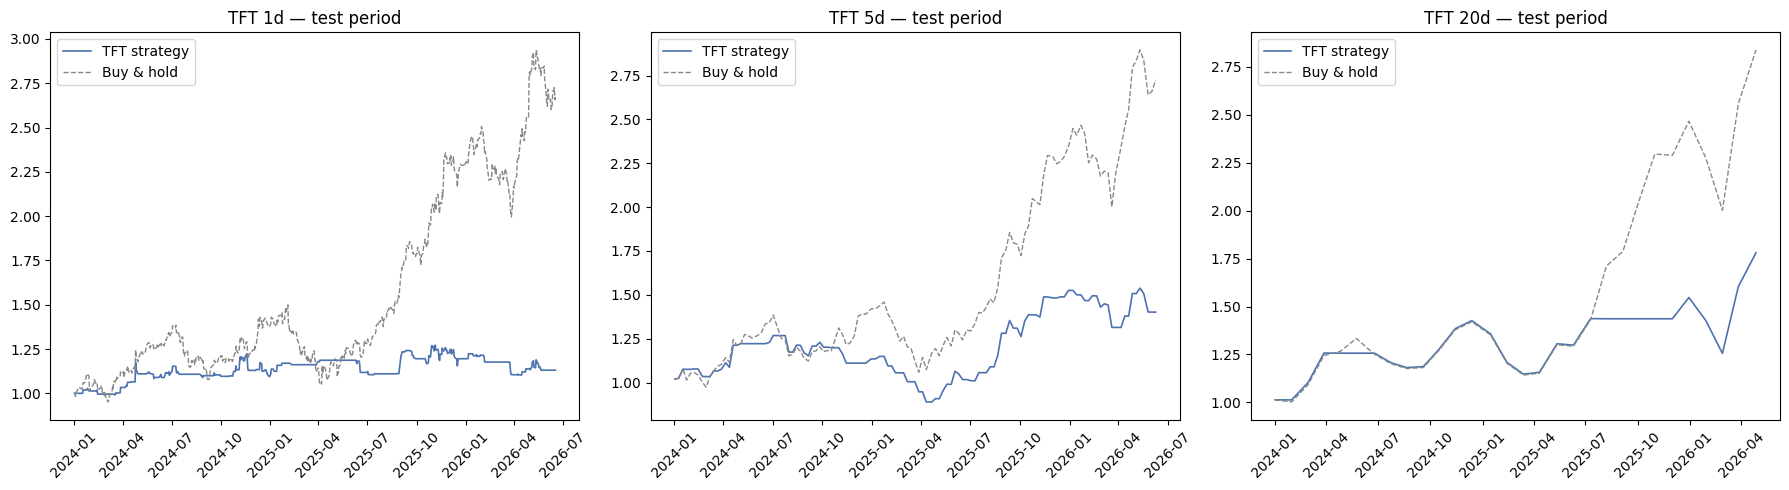

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, horizon in zip(axes, ["1d", "5d", "20d"]):
    r = strategy_results[horizon]["test"]
    ax.plot(r["cumulative_strategy"].index, r["cumulative_strategy"],
            label="TFT strategy", color="#4C72B0", linewidth=1.2)
    ax.plot(r["cumulative_bh"].index, r["cumulative_bh"],
            label="Buy & hold", color="#888888", linewidth=1.0, linestyle="--")
    ax.set_title(f"TFT {horizon} — test period")
    ax.legend()
    ax.tick_params(axis="x", rotation=45)
 
plt.tight_layout()
plt.savefig("tft_strategy_performance.png", dpi=120, bbox_inches="tight")
plt.show()

In [32]:
for target_col in TARGET_COLS:
    horizon = HORIZONS[target_col]
    best_path, tft_df, train_ds, _ = tft_model_paths[horizon]
 
    model = TemporalFusionTransformer.load_from_checkpoint(best_path)
    model.eval()
 
    pred_ds = TimeSeriesDataSet.from_dataset(
        train_ds,
        tft_df.tail(ENCODER_LENGTH + 100),
        predict=True,
        stop_randomization=True,
    )
    pred_loader = pred_ds.to_dataloader(train=False, batch_size=64, num_workers=2)
 
    with torch.no_grad():
        interpretation = model.interpret_output(
            model.predict(pred_loader, mode="raw", return_index=True)[0],
            reduction="sum",
        )
 
    encoder_importance = pd.Series(
        interpretation["encoder_variables"].cpu().numpy(),
        index=model.encoder_variables,
    ).sort_values(ascending=False)
 
    print(f"\nTop 15 encoder variable importance — {horizon}:")
    print(encoder_importance.head(15).to_string())

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]



Top 15 encoder variable importance — 1d:
fcf_yield                0.313470
stoch_d                  0.097722
price_corr_nasdaq_60d    0.066897
oil_price_wti_5d_chg     0.048163
revenue_qoq              0.048098
treasury_10y_5d_chg      0.026674
pf_liquidity_inc         0.010457
bb_width                 0.009924
op_income_qoq            0.009907
price_to_ema_10          0.009610
pf_no_dilution           0.009597
wick_lower_ratio         0.009257
adx_14                   0.009000
macd_hist                0.008908
volume_ratio_5_20        0.008802


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]



Top 15 encoder variable importance — 5d:
log_return_3d            0.119534
oil_price_wti_20d_chg    0.062194
stoch_k                  0.040723
op_income_qoq            0.034685
volume_ratio_20_60       0.032442
volume_ratio_5_20        0.025072
dmn_14                   0.023380
price_corr_nasdaq_60d    0.021840
volume_zscore_20         0.021573
eps_qoq                  0.017124
vix_5d_chg               0.015753
gdp_qoq                  0.015414
wick_upper_ratio         0.014872
treasury_10y_5d_chg      0.014141
macd_signal              0.013841


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]



Top 15 encoder variable importance — 20d:
hvol_10d                  0.157987
dda                       0.099505
short_term_investments    0.088452
donchian_width            0.067639
googl_vs_nasdaq_20d       0.036614
log_return_60d            0.031823
pf_margin_inc             0.030289
obv_momentum              0.029130
wick_lower_ratio          0.021901
bb_position               0.017814
usd_index_5d_chg          0.014026
raw_dda                   0.012315
fcf_margin                0.011434
sga_ratio                 0.010186
vix_regime                0.008839


In [35]:
pred_combined = {}
for target_col in TARGET_COLS:
    horizon = HORIZONS[target_col]
    preds   = all_preds[horizon]
    pred_combined[f"pred_{horizon}"]   = preds["pred"]
    pred_combined[f"actual_{horizon}"] = preds["actual"]
 
predictions_df = pd.DataFrame(pred_combined)
predictions_df.to_csv("tft_predictions.csv")
 
tft_metrics = {
    "regression" : regression_results,
    "directional": directional_results,
    "strategy"   : {
        h: {s: {k: v for k, v in r.items()
                if not isinstance(v, (pd.Series, np.ndarray))}
            for s, r in splits.items()}
        for h, splits in strategy_results.items()
    },
}
 
with open("tft_metrics.json", "w") as fh:
    json.dump(tft_metrics, fh, indent=2)

print("  PART 5 SUMMARY — TEMPORAL FUSION TRANSFORMER")
for horizon in ["1d", "5d", "20d"]:
    r_reg  = regression_results[horizon]["test"]
    r_dir  = directional_results[horizon]["test"]
    r_str  = strategy_results[horizon]["test"]
    print(f"\n  {horizon} horizon (test set):")
    print(f"    MAE              : {r_reg['mae']:.5f}")
    print(f"    Directional acc  : {r_dir['accuracy']:.4f}  (base rate: {r_dir['base_rate']:.4f})")
    print(f"    Strategy Sharpe  : {r_str['sharpe_ratio']:.3f}  (buy-hold: {r_str['buy_hold_sharpe']:.3f})")
    print(f"    Strategy return  : {r_str['total_return']:+.3f}  (buy-hold: {r_str['buy_hold_return']:+.3f})")

print(f"\n  Predictions : tft_predictions.csv")
print(f"  Metrics     : tft_metrics.json")
print("\n  Ready for Part 6: iTransformer")

  PART 5 SUMMARY — TEMPORAL FUSION TRANSFORMER

  1d horizon (test set):
    MAE              : 0.01421
    Directional acc  : 0.4635  (base rate: 0.5527)
    Strategy Sharpe  : 0.391  (buy-hold: 1.483)
    Strategy return  : +0.131  (buy-hold: +1.687)

  5d horizon (test set):
    MAE              : 0.03738
    Directional acc  : 0.4845  (base rate: 0.5889)
    Strategy Sharpe  : 0.720  (buy-hold: 1.532)
    Strategy return  : +0.401  (buy-hold: +1.725)

  20d horizon (test set):
    MAE              : 0.08446
    Directional acc  : 0.4766  (base rate: 0.6488)
    Strategy Sharpe  : 0.985  (buy-hold: 1.526)
    Strategy return  : +0.780  (buy-hold: +1.838)

  Predictions : tft_predictions.csv
  Metrics     : tft_metrics.json

  Ready for Part 6: iTransformer
